<a href="https://www.kaggle.com/code/mumerfarooqbajwa/logistic-regression?scriptVersionId=343460552" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/martaarroyo/palmer-penguins-for-binary-classification/penguins_binary_classification.csv


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("martaarroyo/palmer-penguins-for-binary-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/martaarroyo/palmer-penguins-for-binary-classification


# **Logistic Regression Implementation (Perceptron Trick)**

In [3]:
def perceptron_trick (X, y, lr=.25, epochs = 3500):

    X= np.insert(X, 0, 1, axis=1)
    weights = [1 for i in range(X.shape[1])]

    for i in range(epochs):
        j = np.random.randint(0, X.shape[0])
        y_hat = step(np.dot(X[j], weights))
        #print(y_hat, " ::: ", y[j], " ::: ", weights, " ::: ", end="")
        weights = weights + lr *(y[j]-y_hat)*X[j]
        #print(weights, " ::: ",lr *(y[j]-y_hat)*X[j])


    return weights [0],  weights [1:]

def step(z):
    return 0 if z<=0 else 1

In [4]:
df = pd.read_csv("/kaggle/input/datasets/martaarroyo/palmer-penguins-for-binary-classification/penguins_binary_classification.csv")


In [5]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007
...,...,...,...,...,...,...,...
269,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,2009
270,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,2009
271,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,2009
272,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,2009


In [6]:
df['year'].unique()

array([2007, 2008, 2009])

In [7]:
df['year'].value_counts()

year
2008    96
2009    95
2007    83
Name: count, dtype: int64

In [8]:
df  = df[df['year'] != 2007]

In [9]:
df['year'].unique()

array([2008, 2009])

In [10]:
df['island'].value_counts()

island
Biscoe       123
Dream         36
Torgersen     32
Name: count, dtype: int64

In [11]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
49,Adelie,Biscoe,39.6,17.7,186.0,3500.0,2008
50,Adelie,Biscoe,40.1,18.9,188.0,4300.0,2008
51,Adelie,Biscoe,35.0,17.9,190.0,3450.0,2008
52,Adelie,Biscoe,42.0,19.5,200.0,4050.0,2008
53,Adelie,Biscoe,34.5,18.1,187.0,2900.0,2008
...,...,...,...,...,...,...,...
269,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,2009
270,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,2009
271,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,2009
272,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,2009


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =  train_test_split (df.iloc[:, :-1], df['year'], test_size =0.2)

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ohe= OneHotEncoder(drop="first")
rtf= ColumnTransformer([('ohe', ohe, ['island', 'species'])],
                      remainder='passthrough')

rtf.fit(X_train)
X_train = rtf.transform(X_train)
X_test = rtf.transform(X_test)


In [14]:
intercept, coef=perceptron_trick(X_train, np.array(y_train))

In [15]:
print(intercept)
print(coef)

1756570.25
[3.56350250e+05 2.86078500e+05 8.17033250e+05 7.54490452e+07
 2.94261116e+07 3.57765843e+08 7.61160389e+09]


# **Custom 2D dataset**

In [16]:
from sklearn.datasets import make_classification
import pandas as pd

# Parameters
n_samples = 1000       # number of rows
n_features = 2         # number of input columns (all informative, no redundancy)
n_classes = 2          # binary output
random_state = 42      # for reproducibility

# Generate the dataset
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_features,  # all features are useful
    n_redundant=0,
    n_classes=n_classes,
    random_state=random_state,
    shuffle=False,
    class_sep=10
)

# Combine into a pandas DataFrame (optional, but convenient)
columns = [f"feature_{i+1}" for i in range(n_features)]
df = pd.DataFrame(X, columns=columns)
df["target"] = y

# Check the output
print(df.sample(5))
print("\nUnique values in target:", df["target"].unique())
print("Shape:", df.shape)

     feature_1  feature_2  target
777   9.536134   9.592396       1
336  -9.893538   9.355069       1
596   9.702223  -9.758531       0
100 -10.236030 -10.746845       0
65   -9.732637  -8.707397       0

Unique values in target: [0 1]
Shape: (1000, 3)


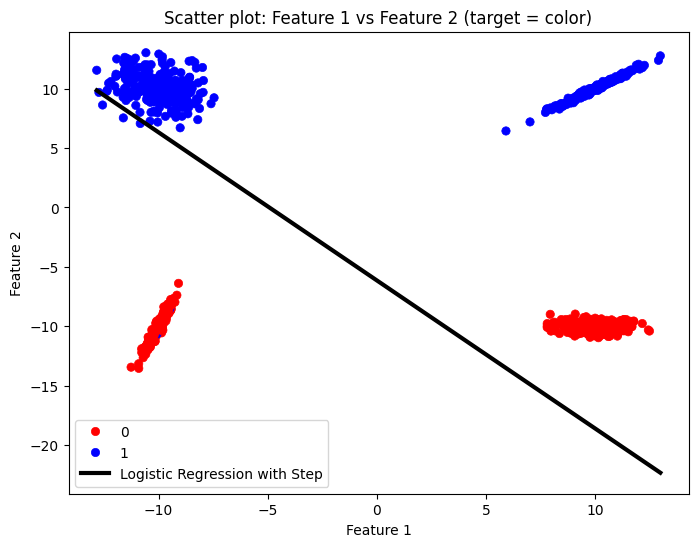

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8, 6))
sns.scatterplot(
    data = df,
    x = "feature_1",
    y = "feature_2",
    hue = "target", # class represented by color
    palette =["red","blue"], #class 0 → red, class 1 → blue    alpha = 0.7, #lign transparency to see overlap
    edgecolor = None
)
plt.title("Scatter plot: Feature 1 vs Feature 2 (target = color)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title = "Target class", labels =["0" ,"1"])

x1_line = np.linspace(df["feature_1"].min(), df["feature_1"].max(), 100)
x2_line = -(intercept + coef[0] * x1_line) / coef[1]
plt.plot(x1_line, x2_line, color="black", linewidth=3, label='Logistic Regression with Step')
plt.legend()

plt.show()

In [18]:
perceptron_trick(X,y)

(np.float64(2.0), array([-1.037169  ,  2.76196982]))

# **Perceptron Trick With Sigmoid Function**

In [19]:
def sigmoid(z):
    return 1/(1+ np.exp(-z))

def perceptron_trick_with_sigmoid (X, y, lr=.25, epochs = 3500):

    X= np.insert(X, 0, 1, axis=1)
    weights = [1 for i in range(X.shape[1])]

    for i in range(epochs):
        j = np.random.randint(0, X.shape[0])
        y_hat = sigmoid(np.dot(X[j], weights))
        #print(y_hat, " ::: ", y[j], " ::: ", weights, " ::: ", end="")
        weights = weights + lr *(y[j]-y_hat)*X[j]
        #print(weights, " ::: ",lr *(y[j]-y_hat)*X[j])


    return weights [0],  weights [1:]

In [20]:
intercept, coef=perceptron_trick_with_sigmoid(np.array(X), np.array(y))

In [21]:
print(intercept)
print(coef)

2.5162251620248135
[1.68006602 2.8122102 ]


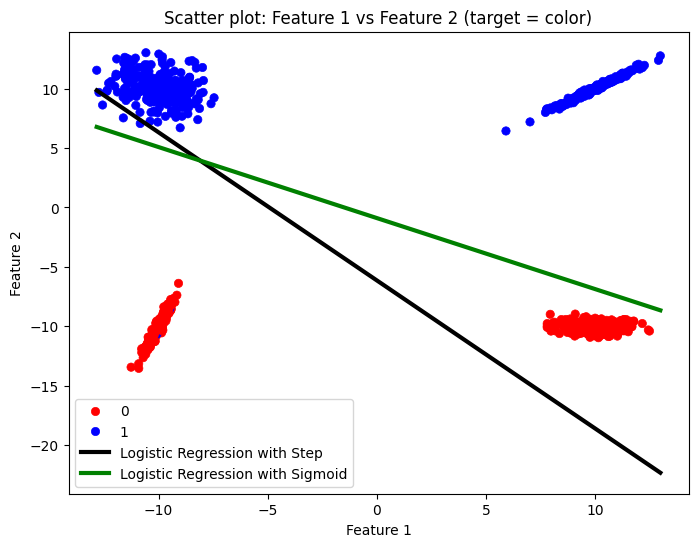

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8, 6))
sns.scatterplot(
    data = df,
    x = "feature_1",
    y = "feature_2",
    hue = "target", # class represented by color
    palette =["red","blue"], #class 0 → red, class 1 → blue    alpha = 0.7, #lign transparency to see overlap
    edgecolor = None
)
plt.title("Scatter plot: Feature 1 vs Feature 2 (target = color)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title = "Target class", labels =["0" ,"1"])

x1_line_sigmoid = np.linspace(df["feature_1"].min(), df["feature_1"].max(), 100)
x2_line_sigmoid = -(intercept + coef[0] * x1_line) / coef[1]
plt.plot(x1_line, x2_line, color="black", linewidth=3, label='Logistic Regression with Step')
plt.plot(x1_line_sigmoid, x2_line_sigmoid, linewidth=3, color="green", label='Logistic Regression with Sigmoid')

plt.legend()

plt.show()

In [23]:
# green line ie logistic regression with sigmoid is better than logistic regression with simple step function

In [24]:
from sklearn.linear_model import LogisticRegression

reg=LogisticRegression(penalty=None, solver='sag')
reg.fit(X,y)
reg.intercept_

x1_line_actual= np.linspace(df["feature_1"].min(), df["feature_1"].max(), 100)
x2_line_actual = -(reg.intercept_ + reg.coef_[0][0] * x1_line_actual) / reg.coef_[0][1]


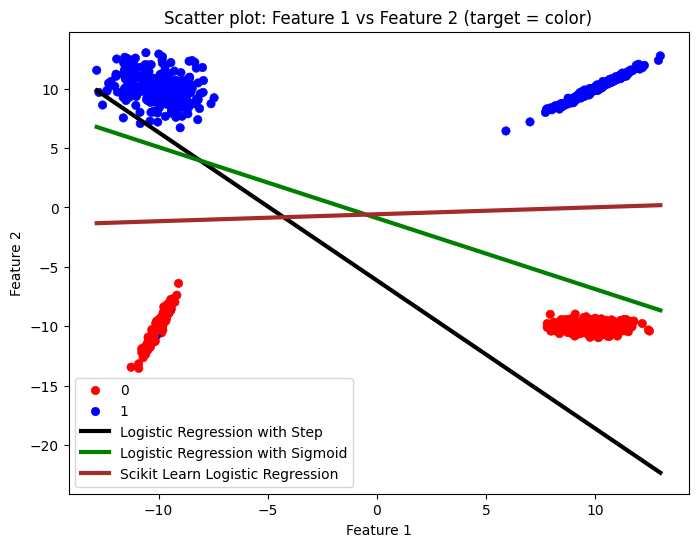

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8, 6))
sns.scatterplot(
    data = df,
    x = "feature_1",
    y = "feature_2",
    hue = "target", # class represented by color
    palette =["red","blue"], #class 0 → red, class 1 → blue    alpha = 0.7, #lign transparency to see overlap
    edgecolor = None
)
plt.title("Scatter plot: Feature 1 vs Feature 2 (target = color)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title = "Target class", labels =["0" ,"1"])

x1_line_sigmoid = np.linspace(df["feature_1"].min(), df["feature_1"].max(), 100)
x2_line_sigmoid = -(intercept + coef[0] * x1_line) / coef[1]
plt.plot(x1_line, x2_line, color="black", linewidth=3, label='Logistic Regression with Step')
plt.plot(x1_line_sigmoid, x2_line_sigmoid, linewidth=3, color="green", label='Logistic Regression with Sigmoid')
plt.plot(x1_line_actual, x2_line_actual, color="brown", linewidth=3, label='Scikit Learn Logistic Regression')


plt.legend()

plt.show()

In [26]:
# both sklearn line and line with sigmoid almost overlaps

# A Function to Measure Performance

if you have 2 lines and want to compare performance of both ypu have to use a way/function for it. first we have a basic function.

we calculate the liklihood (probabiblity) of resulting class of each point/row then we multiply probabilities of all points/rows/records wrt. to both models. whose value is greater, it's performing better. 

but as you know probability is always [0,1] ie may be a decimal value so multiplying probablities (decimal values) of thousands of rows will give a very small number, handling which can be difficult. so we have a solution for this. like a,b,c are probabilities of X1, X2, X3  etc then we apply log in such way:
abc
log(abc)
= log a + log b+ log c

so we know the log of any number from 0 to 1 is always a negative number so we apply negative with the log to make the effect positive.

loss =  - log a - log b - log c - ... 


evetually the loss function became:

**loss = -1/m * Σ ( y(log y_hat) + (1-y) log(1 - y_hat) )**

In [27]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1/(1 + np.exp(-z))


class MyLogisticRegression:
    def __init__ (self, epochs=1000, learning_rate=0.1):
        self.epochs = epochs
        self.learning_rate=learning_rate
        self.intercept_ = None
        self.coef_ = None

    def fit(self, X_train, y_train):
        weights = [0 for i in range(X_train.shape[1])]
        weights = np.insert (weights, 0,0)

        X_train = np.insert(X_train, 0, 1, axis=1)

        for i in range(self.epochs):            
            y_hat = sigmoid (np.dot(X_train , weights))

            weights = weights- self.learning_rate * np.dot( (y_train - y_hat), X_train) / y_train.shape[0]

        self.intercept_ = weights[0]
        self.coef_ = weights [1:]

    def predict (X_test):
        return  (sigmoid(np.dot( self.coef_ , X_test ) + self.intercept_)>=0.5).astype(int)

In [28]:
reg=MyLogisticRegression(learning_rate = 0.25, epochs=3500)
reg.fit(X,y)
reg.intercept_

x1_line_myLR= np.linspace(df["feature_1"].min(), df["feature_1"].max(), 100)
x2_line_myLR = -(reg.intercept_ + reg.coef_[0] * x1_line_myLR) / reg.coef_[0]


In [29]:
x1_line_myLR

array([-12.83692921, -12.57600423, -12.31507925, -12.05415427,
       -11.79322928, -11.5323043 , -11.27137932, -11.01045434,
       -10.74952936, -10.48860437, -10.22767939,  -9.96675441,
        -9.70582943,  -9.44490445,  -9.18397946,  -8.92305448,
        -8.6621295 ,  -8.40120452,  -8.14027953,  -7.87935455,
        -7.61842957,  -7.35750459,  -7.09657961,  -6.83565462,
        -6.57472964,  -6.31380466,  -6.05287968,  -5.7919547 ,
        -5.53102971,  -5.27010473,  -5.00917975,  -4.74825477,
        -4.48732979,  -4.2264048 ,  -3.96547982,  -3.70455484,
        -3.44362986,  -3.18270488,  -2.92177989,  -2.66085491,
        -2.39992993,  -2.13900495,  -1.87807997,  -1.61715498,
        -1.35623   ,  -1.09530502,  -0.83438004,  -0.57345506,
        -0.31253007,  -0.05160509,   0.20931989,   0.47024487,
         0.73116985,   0.99209484,   1.25301982,   1.5139448 ,
         1.77486978,   2.03579476,   2.29671975,   2.55764473,
         2.81856971,   3.07949469,   3.34041968,   3.60

In [30]:
x2_line_myLR

array([ 12.88920419,  12.62827921,  12.36735423,  12.10642925,
        11.84550426,  11.58457928,  11.3236543 ,  11.06272932,
        10.80180434,  10.54087935,  10.27995437,  10.01902939,
         9.75810441,   9.49717943,   9.23625444,   8.97532946,
         8.71440448,   8.4534795 ,   8.19255452,   7.93162953,
         7.67070455,   7.40977957,   7.14885459,   6.8879296 ,
         6.62700462,   6.36607964,   6.10515466,   5.84422968,
         5.58330469,   5.32237971,   5.06145473,   4.80052975,
         4.53960477,   4.27867978,   4.0177548 ,   3.75682982,
         3.49590484,   3.23497986,   2.97405487,   2.71312989,
         2.45220491,   2.19127993,   1.93035495,   1.66942996,
         1.40850498,   1.14758   ,   0.88665502,   0.62573004,
         0.36480505,   0.10388007,  -0.15704491,  -0.41796989,
        -0.67889487,  -0.93981986,  -1.20074484,  -1.46166982,
        -1.7225948 ,  -1.98351978,  -2.24444477,  -2.50536975,
        -2.76629473,  -3.02721971,  -3.28814469,  -3.54

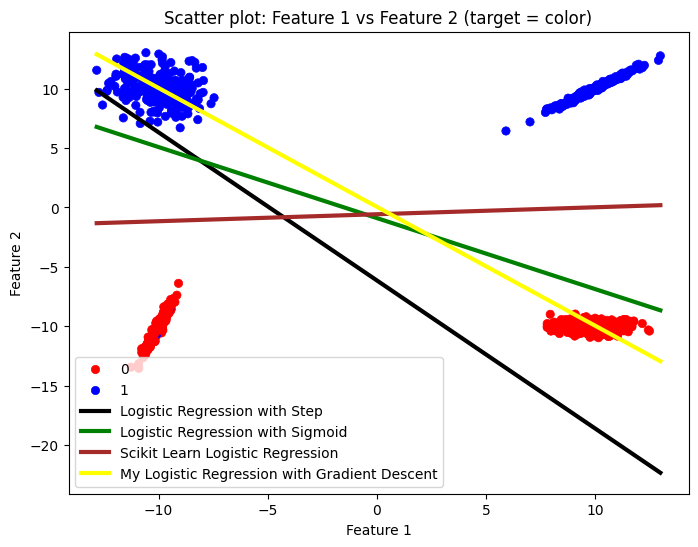

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8, 6))
sns.scatterplot(
    data = df,
    x = "feature_1",
    y = "feature_2",
    hue = "target", # class represented by color
    palette =["red","blue"], #class 0 → red, class 1 → blue    alpha = 0.7, #lign transparency to see overlap
    edgecolor = None
)
plt.title("Scatter plot: Feature 1 vs Feature 2 (target = color)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title = "Target class", labels =["0" ,"1"])

x1_line_sigmoid = np.linspace(df["feature_1"].min(), df["feature_1"].max(), 100)
x2_line_sigmoid = -(intercept + coef[0] * x1_line) / coef[1]
plt.plot(x1_line, x2_line, color="black", linewidth=3, label='Logistic Regression with Step')
plt.plot(x1_line_sigmoid, x2_line_sigmoid, linewidth=3, color="green", label='Logistic Regression with Sigmoid')
plt.plot(x1_line_actual, x2_line_actual, color="brown", linewidth=3, label='Scikit Learn Logistic Regression')
plt.plot(x1_line_myLR, x2_line_myLR, color="yellow", linewidth=3, label='My Logistic Regression with Gradient Descent')



plt.legend()

plt.show()

# **Softmax Logistic Regression (Multinomial/ Multiclass)**

**if we have multiple (more than 2) classes in target column as output, instead of binary approach of logistic regression, softmax regression is used.**

# Internal Working

lets suppose target feature has 3 unique values/classes as like car, bike, cycle as output. first step will be introducing 3 columns ie car, bike, cycle. it will be basically splitting of target column into 3 columns. column car will have value 1 for the rows/records with target value of output as "car", values for other rows will be 0. same way for other two new columns ie bike, cycle. 

now we have 3 columns (binary) as output instead of one.

now we we alter the loss function of logistic regression from:

loss = -1/m * Σ y log y_hat + (1 - y) log (1 - y_hat)

to

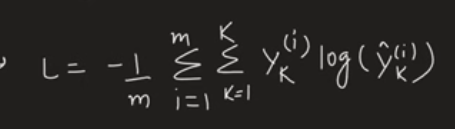

outer summation is for 1 to m all rows, and inner summation is for 1 to K all separate output columns. 

it means simply:

L = -1/m * Σ ( y_car * log (y_hat_car) + y_bike * log(y_hat_bike) + y_cycle* log(y_hat_cycle ) )

this summation is for all rows 1 to m.

softmax activation function for prediction is:

σ (zi) = e^zi / Σ e^zi   

zi is basically ith z. it is written in such way due to unavailbility of way to write it.

then use this function derivative for weights update.

**One Important Thing!**
in binary logistic regression, there is only one set of weights for the model, but in softmax we have the number of sets of weights which target column has unique classes ie 3 in this case, so basically weights is 2 D matrix here.
(basically internally we need 3 models to predict is it car? is it bike? is it cycle?)

# **DataSet for Softmax Regression**

In [32]:
from sklearn.datasets import make_classification
import pandas as pd

# Parameters
n_samples = 1000
n_features = 2
n_classes = 3
random_state = 42

# Generate the dataset
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_features,
    n_redundant=0,
    n_classes=n_classes,
    n_clusters_per_class=1,   # <-- Fix: one cluster per class
    random_state=random_state,
    shuffle=False,
    class_sep=10
)

# Combine into DataFrame
columns = [f"feature_{i+1}" for i in range(n_features)]
df = pd.DataFrame(X, columns=columns)
df["target"] = y

print(df.sample(5))
print("\nUnique values in target:", df["target"].unique())
print("Shape:", df.shape)

     feature_1  feature_2  target
47   -9.928602  10.003360       0
309  -9.470347  11.037134       0
922 -11.581342 -10.357166       2
326 -10.741572   8.050939       0
287  -9.596025  10.506905       0

Unique values in target: [0 1 2]
Shape: (1000, 3)


In [33]:
df.sample(5)

,feature_1,feature_2,target
928,-10.090977,-9.891821,2
822,-9.260999,-9.591971,2
369,11.516846,8.837323,1
186,-11.124081,7.637751,0
649,10.616256,8.994205,1


In [34]:
df['target'].value_counts()

target
2    335
1    333
0    332
Name: count, dtype: int64

# Using Sklearn.LogisticRegression

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
reg = LogisticRegression(multi_class='multinomial')

In [37]:
X_train, X_test, y_train, y_test= train_test_split (X,y, test_size=0.2, random_state=np.random.randint(1,101))

In [38]:
reg.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [39]:
y_predicted = reg.predict ( X_test)

In [40]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

In [41]:
f1_score(y_predicted, y_test,average='weighted')

0.9949957256526599

In [42]:
accuracy_score(y_predicted, y_test)

0.995

In [43]:
confusion_matrix(y_predicted, y_test)

array([[55,  1,  0],
       [ 0, 68,  0],
       [ 0,  0, 76]])